# Нейросеть для автодополнения текстов

<div class='alert alert-info'> 

Финальное задание спринта 2. 

Задача – создать нейросеть, которая на основе начала фразы предсказывает её продолжение. 

Последовательность работы: 

1. Взять датасет, очистить его, подготовить для обучения модели.
2. Реализовать и обучить модель на основе рекуррентных нейронных сетей.
3. Замерить качество разработанной и обученной модели.
4. Взять более «тяжёлую» предобученную модель из Transformers и замерить её качество.
5. Проанализировать результаты и дать рекомендации разработчикам: стоит ли использовать лёгкую модель или лучше постараться поработать с ограничениями по памяти и использовать большую предобученную.

</div>

<div class='alert alert-info'>

**Этап 0. Подготовка окружения**

[x] Подготовьте окружение. Используйте файл `requirements_sprint_2_project.txt`.

[x] Создайте git-репозиторий. Подумайте над структурой проекта. Можете заранее создать некоторые файлы, в которых будете писать код.

**Этап 1. Сбор и подготовка данных**

[x] Скачайте датасет, положите его в папку `data`.

[x] «Почистите» тексты в датасете, а затем токенизируйте их. Для удобства можете сохранить почищенный и токенизированный датасет.

[x] Разбейте датасет на трейн, валидацию и тест.

[x] Создайте `torch.Dataset` и `torch.DataLoader` для обучения модели.

**Этап 2. Реализация рекуррентной сети**

[x] Напишите код модели на основе `LSTM`. В методе `forward` модель должна принимать на вход последовательность токенов и предсказывать следующий токен.

[x] Дополнительно для модели реализуйте метод генерации нескольких токенов.

**Этап 3. Тренировка модели**

[x] Напишите код замера и вывода метрики `ROUGE`. В коде модель должна проходиться по `DataLoader`'у и генерировать автодополнения, которые затем будут сравниваться с таргетом. 

[x] Для простоты реализуйте сценарий, где в качестве входа модель получает 3/4 исходного текста и старается дополнить оставшиеся 1/4.

[x] Напишите код тренировки модели, во время тренировки выводите значения функции потерь и метрики ROUGE.

[x] Обучите модель, подобрав оптимальные параметры. 

[x] Во время тренировки или после неё выведите некоторые примеры автодополнений, которые выучила модель. 

*Ориентировочное время тренировки: несколько минут на одну эпоху при размере батча около 256 и размерности скрытого слоя LSTM около 128. Так как тексты ограничены по длине, а памяти на видеокарте хватает с запасом, то можно ставить размер батча и размерности модели и побольше.*

**Этап 4. Использование предобученного трансформера**

[x] Воспользуйтесь моделью трансформера `distilgpt2` из `Transformers` и дополните тексты из датасета.

[x] Напишите код замера и вывода метрики `ROUGE`, но уже с использованием трансформера. Здесь, как и с `LSTM`, предсказывайте последнюю четверть текста.

[x] Подберите параметры генерации, замерьте качество модели на валидационной выборке, выведите примеры предсказаний.

**Этап 5. Формулирование выводов**

[ ] Сравните примеры предсказаний двух моделей, а также получившиеся метрики.

[ ] Сделайте выводы о том, какую модель лучше использовать и почему.

</div>

## Загрузка библиотек, установка констант

In [1]:
import os
# import random
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
from scipy.stats import mode
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers import logging
from transformers import pipeline


In [2]:
# traditionally, 
SEED = 42
# Train mode; if 'preliminar', just verify the code, 
# if 'final' – train the ultimate models versions. 
# When 'preliminar' mode is switched on, reduce the
# data volume to 1_000 tweets, batch size to 64 
# and print some test messages if CHECK_MESSAGES 
# is True. 
TRAIN_MODE = 'preliminar' 
CHECK_MESSAGES = False
# name of transformer model
MODEL_NAME = 'distilgpt2'
# batch size
if TRAIN_MODE == 'preliminar': 
    BATCH_SIZE = 64
else: 
    BATCH_SIZE = 512


## Обработка данных

<div class='alert alert-info'>

Данные нужно 

- привести к нижнему регистру;
- удалить ссылки, упоминания, эмодзи (по необходимости);
- заменить нестандартные символы;
- токенизировать текст.

</div>

### Загрузка данных

In [3]:
# set data directory
os.chdir('C:/Users/User/Yandex.Disk/DS.projects/LSTM.Praktikum/data')
# read raw text data and save to array
with open('raw_data.txt', 'r', encoding='utf-8') as file:
    raw_data = np.array(file.read().lower().splitlines())

if TRAIN_MODE == 'preliminar': 
    raw_data = raw_data[:1_000]

### Очистка данных

<div class='alert alert-success'>

Вычищает то, что следует удалить, со всех позиций (начало, середина, конец фразы). Проверено. 

</div>

In [4]:
# define the function for clearing and splitting of data
def split_and_clean(row): 
    # remove the mentions (@*)
    row = re.sub(r'@.*?\s', '', row)
    row = re.sub(r'@.*?\Z', '', row)

    # remove the URLs (http or www)
    row = re.sub(r'www.*?\s', '', row)
    row = re.sub(r'http.*?\s', '', row)
    row = re.sub(r'www.*?\Z', '', row)
    row = re.sub(r'http.*?\Z', '', row)

    # remove emojies ('*...anything')
    row = re.sub(r'\*([^ ]+)\s', '', row)
    row = re.sub(r'\*([^ ]+)\Z', '', row)

    # remove special symbols (&*;)
    row = re.sub(r'&([^ ]+)\;', '', row)

    # remove everything except of letters and numbers
    row = re.sub(r'[^a-z0-9\s]', '', row)

    # substitute the multiple spaces to single ones
    row = re.sub(r'[\s+]', ' ', row)

    # split the strings by spaces
    row = row.split(' ')

    # remove the empty elements from lists
    row = list(filter(None, row))
    
    return(row)

raw_data = list(map(split_and_clean, raw_data))

In [5]:
# check the result of raw data import (deliberabely without seed)
if TRAIN_MODE == 'preliminar': 
    for _ in np.random.randint(0, len(raw_data), 10): 
        print(raw_data[_])

['one', 'less', 'follower', 'tonight']
['yup']
['essay', 'time']
['i', 'still', 'havent', 'read', 'the', '9th10th', 'princess', 'diaries', 'saving', 'francesca', 'made', 'me', 'cry', 'at', 'the', 'end', 'hmm', 'those', 'are', 'easy', 'books']
['brat', 'you', 'have', 'to', 'rub', 'it', 'in', 'dont', 'you', 'i', 'want', 'a', 'mocha']
['uh', 'oh', 'i', 'think', 'i', 'am', 'getting', 'sick']
['laid', 'around', 'too', 'much', 'today', 'now', 'my', 'head', 'hurts']
['damnit', 'i', 'was', 'really', 'digging', 'this', 'season', 'of', 'reaper']
['completely', 'wiped', 'and', 'reloaded', 'the', '8900', 'lost', 'all', 'bbm', 'contacts', 'going', 'to', 'bed', 'sad']
['me', 'too', 'i', 'is', 'poor']


<div class='alert alert-info'>

Поскольку по условию задания модель получает на вход 3/4 исходного текста, фразы, в которых осталось три слова и менее, следует удалить. Более того, из-за использования `ROUGE-2` как одной из метрик, удалять надо тексты, в которых четвёртая часть равна двум словам, т.е., общая длина не менее шести. 

Итого: вычищаем из корпуса текстов все последовательности короче шести слов.

</div>

In [6]:
print(f'Количество фраз до удаления слишком коротких: {len(raw_data)}.')
# drop too short phrases
raw_data = [phrase for phrase in raw_data if len(phrase) > 5]

# check the results
print(f'Количество фраз после удаления слишком коротких: {len(raw_data)}.')
if len(min(raw_data, key=len)) < 6: 
    print('Очистка от коротких фраз прошла с ошибкой.')
else: 
    print('Все короткие фразы удалены.')


Количество фраз до удаления слишком коротких: 1000.
Количество фраз после удаления слишком коротких: 849.
Все короткие фразы удалены.


In [7]:
# save the processed (cleaned) dataset
with open('processed_data.txt', 'w+', encoding='utf-8') as file: 
    for row in raw_data:
        file.write(' '.join(row) + '\n')

### Разбиение данных

<div class='alert alert-info'>

По условию задания, обучающая выборка 80%, валидационная и тестовая по 10%.

</div>

In [8]:
# create train, test and valid datasets
train, interhim = train_test_split(raw_data, train_size=0.8, random_state=SEED)
valid, test = train_test_split(interhim, train_size=0.5, random_state=SEED)

del interhim

# check splitting
print(f'В обучающей выборке содержится {len(train)} фраз.')
print(f'В валидационной выборке содержится {len(valid)} фраз.')
print(f'В тестовой выборке содержится {len(test)} фраз.')

В обучающей выборке содержится 679 фраз.
В валидационной выборке содержится 85 фраз.
В тестовой выборке содержится 85 фраз.


In [9]:
# save the datasets to disk
with open('train.txt', 'w+', encoding='utf-8') as file: 
    for row in train:
        file.write(' '.join(row) + '\n')
with open('valid.txt', 'w+', encoding='utf-8') as file: 
    for row in valid:
        file.write(' '.join(row) + '\n')
with open('test.txt', 'w+', encoding='utf-8') as file: 
    for row in test:
        file.write(' '.join(row) + '\n')

## Подготовка к токенизации данных и их загрузке в модель

In [10]:
# add pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, add_prefix_space=True)
if TRAIN_MODE == 'preliminar': 
    print(tokenizer)

tokenizer.pad_token = tokenizer.eos_token

GPT2Tokenizer(name_or_path='distilgpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)


In [11]:
# check the results of tokenization
if TRAIN_MODE == 'preliminar': 
    example_phrase = raw_data[np.random.randint(0, len(raw_data), 1).item()]
    print(tokenizer.encode(
        example_phrase, 
        is_split_into_words=True, 
        add_special_tokens=True, 
        return_tensors='pt')
        )
    print('Длина фразы после энкодинга: ', len(tokenizer.encode(
        example_phrase, 
        is_split_into_words=True, 
        add_special_tokens=True, 
        return_tensors='pt')[0])
        )
    print(tokenizer.tokenize(
        example_phrase, 
        is_split_into_words=True, 
        return_tensors='pt'
        )
        )
    print('Длина токенизированной фразы: ', len(tokenizer.tokenize(
        example_phrase, 
        is_split_into_words=True, 
        return_tensors='pt')
        )
    )
    print(example_phrase)
    print('Длина исходной фразы: ', len(example_phrase))

tensor([[ 545, 1654,  345,  260,  826, 1312,  761,  284,  923, 1762,  503,  351,
          345,  290,  262,  299, 1134, 1706,  393,  474, 1144,  379, 1551]])
Длина фразы после энкодинга:  23
['Ġim', 'Ġsure', 'Ġyou', 're', 'Ġright', 'Ġi', 'Ġneed', 'Ġto', 'Ġstart', 'Ġworking', 'Ġout', 'Ġwith', 'Ġyou', 'Ġand', 'Ġthe', 'Ġn', 'ik', 'ster', 'Ġor', 'Ġj', 'ared', 'Ġat', 'Ġleast']
Длина токенизированной фразы:  23
['im', 'sure', 'youre', 'right', 'i', 'need', 'to', 'start', 'working', 'out', 'with', 'you', 'and', 'the', 'nikster', 'or', 'jared', 'at', 'least']
Длина исходной фразы:  19


In [12]:
def tokenize(row):
    return tokenizer.encode(
        row, is_split_into_words=True, add_special_tokens=True, return_tensors='pt', 
        )

In [13]:
# класс датасета
class MaskedDataset(Dataset):
    def __init__(self, texts, tokenizer=tokenize, target_mode='single'):
        # the list for pairs, including the start of tokenized text and their end
        self.samples = []

        for line in texts: 
            # tokenize the text
            token_ids = tokenizer(line) 
            # create a context (the known 75% of tokens)
            context = token_ids[0][0:(3 * len(token_ids[0]) // 4)] 
            if target_mode == 'complete': 
                # create a target (the last 25% of tokens which must be reconstructed)
                target = token_ids[0][(3 * len(token_ids[0]) // 4):] 
            elif target_mode == 'single': 
                # create a target (the single token following to first 75% of tokens)
                target = token_ids[0][(3 * len(token_ids[0]) // 4) ]
            # join the 'context' and 'target' as tulpe and add to 'samples'
            self.samples.append((context, target))
           
    def __len__(self):
        # return the length of samples
        return len(self.samples) 

    def __getitem__(self, idx):
        # return the context and target with given number ('idx')
        x, y = self.samples[idx] 
        return {
            'context': x.detach().clone(), 
            'target': y.detach().clone()
        }

In [14]:
if TRAIN_MODE == 'preliminar': 
    print('Пример содержимого класса MaskedDataset: ')
    print(MaskedDataset(train, tokenize)[np.random.randint(0, len(train), 1).item()])

Пример содержимого класса MaskedDataset: 
{'context': tensor([ 5176,   257,  1256,  4499,   257,  1256,   286,   649,  2456,   475,
        42547,  1064]), 'target': tensor(644)}


In [15]:
# create tokenized datasets
train_tok = MaskedDataset(train, tokenize)
valid_tok = MaskedDataset(valid, tokenize)
test_tok = MaskedDataset(test, tokenize)
test_tok_complete = MaskedDataset(test, tokenize, 'complete')

In [16]:
def collate_fn(batch): 
    # список текстов и классов из батча
    contexts = [item['context'] for item in batch]
    targets = torch.stack([item['target'] for item in batch])

    # дополняем тексты в батче padding'ом
    padded_contexts = pad_sequence(contexts, batch_first=True, padding_value=0)

    # lengths = [len(text) for text in texts]
    lengths = torch.tensor([len(text) for text in contexts])
    # считаем маски
    masks = (padded_contexts != 0).long()

    # возвращаем преобразованный батч
    return padded_contexts, masks, lengths, targets

In [17]:
if TRAIN_MODE == 'preliminar': 
    print('Размеры выдачи функции collate_fn (без разделения на батчи): ')
    padded_contexts, masks, lengths, targets = collate_fn(train_tok)
    print(padded_contexts.shape)
    print(masks.shape)
    print(lengths.shape)
    print(targets.shape)


Размеры выдачи функции collate_fn (без разделения на батчи): 
torch.Size([679, 27])
torch.Size([679, 27])
torch.Size([679])
torch.Size([679])


In [18]:
# create dataloaders
train_dataloader = DataLoader(
    train_tok, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
    )
valid_dataloader = DataLoader(
    valid_tok, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
    )
test_dataloader = DataLoader(
    test_tok, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
    )
test_compl_dataloader = DataLoader(
    test_tok_complete, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
    )

In [19]:
if TRAIN_MODE == 'preliminar': 
    print(f'Количество батчей в train_dataloader: {len(train_dataloader)}')
    print(f'Размер батча равен {BATCH_SIZE}')
    print()
    for x_batch, masks, lengths, y_batch in train_dataloader: 
        print('Содержимое контекстов в батче: ')
        print(x_batch)
        print(f'Размерность тензора с контекстом: {x_batch.shape}')
        print()
        print('Содержимое таргетов в батче: ')
        print(y_batch)
        print(f'Размерность тензора с таргетом: {y_batch.shape}')
        break

Количество батчей в train_dataloader: 11
Размер батча равен 64

Содержимое контекстов в батче: 
tensor([[ 3387,  1560,   502,  ...,     0,     0,     0],
        [ 1312,   655, 17666,  ...,     0,     0,     0],
        [  220,   425,   587,  ...,     0,     0,     0],
        ...,
        [ 4756,   257, 12387,  ...,     0,     0,     0],
        [ 1282,   284,   262,  ...,     0,     0,     0],
        [  318, 20654,   284,  ...,     0,     0,     0]])
Размерность тензора с контекстом: torch.Size([64, 27])

Содержимое таргетов в батче: 
tensor([  361, 15707,   329, 13224,  1804,   991,  6265,   545,  3407,  2220,
         1468,   262,  6729,   318,  1283, 27309,   845,   351,   616,   318,
          644,  3993, 13140,   319, 12785, 11544,  1643,   329,   329,   649,
          286,   573,   284,  1312,  1216,   257,  6391, 28329,   649,   286,
          257,  4601,  4493,   334,  6175,  3492,   612,   351, 31777,   588,
          484, 26471,   407,  1755,   319,   547,   517,   407,   

## Рекуррентная сеть

<div class='alert alert-info'>

Условия выполнения этапа: 

- Напишите код модели на основе LSTM. 
- В методе `forward` модель должна принимать на вход последовательность токенов и предсказывать следующий токен.
- Дополнительно для модели реализуйте метод генерации нескольких токенов.

</div>

<div class='alert alert-info'>

Последовательность работы модели: 

1. Модель получает на вход начальную последовательность токенов *X*.
2. Затем она предсказывает вероятности следующего токена *P*(*w*<sub>n+1</sub>).
3. Токен *w*<sub>n+1</sub>, имеющий наибольшую вероятность, добавляется к последовательности. 
4. Модель снова делает предсказание *P*(*w*<sub>n+2</sub>).
5. Процесс повторяется, пока не выполнится одно из условий:
    - сгенерирован токен окончания (например, `<eos>`)
    - или достигнута максимальная длина генерации.

</div>

### Создание рекуррентной сети и сопутствующих функций

In [20]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, hidden_dim=256):
        super().__init__()

        # embedding layer
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)

        # out_dim for sum
        # NB: change if summ will be changed to concatenation
        out_dim = hidden_dim 

        # output linear layer
        self.fc = nn.Linear(out_dim, vocab_size)

    def forward(self, x, lengths): 
        # embed the text
        emb = self.embedding(x) 
        if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
            print('Размерность эмбеддинга: ', emb.shape)
        pack = pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
        # get the output of recurrent layer ('out')
        out, _ = self.rnn(pack) 
        out, _ = pad_packed_sequence(out, batch_first=True)
        if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
            print('Размерность выходных данных RNN после pad_packed_sequence: ', out.shape)

        # скрытые состояния <MSAK> токена 
        # после двух проходов двунаправленной сети
        hidden_forward = out[:, :, :out.size(2) // 2]
        hidden_backward = out[:, :, out.size(2) // 2:]

        # агрегация скрытых состояний в зависимости от self.combine
        hidden_agg = hidden_forward + hidden_backward
        if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
            print('Размерность выхода скрытых слоёв: ', hidden_agg.shape)

        linear_out = self.fc(hidden_agg)
        if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
            print('Размерность выхода линейного слоя: ', linear_out.shape)

        return linear_out

In [ ]:
# create an exemplar of LSTM model
model_lstm = LSTMClassifier(vocab_size=tokenizer.vocab_size)
# create an optimizer
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
# set the cross-entropy loss calculator
criterion = nn.CrossEntropyLoss()


In [ ]:
# set the ROUGE scorer
metric_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=True)

In [ ]:
# функция замера лосса и accuracy for the single output token
def evaluate_single_token(model, loader):

    # switch model to inference regime
    model.eval()

    # Set initial values of correct predictions and batch size 
    # to calculate accuracy.
    correct, total_batch_size = 0, 0
    # set initial value of loss sum for the given epoch
    sum_loss = 0

    # calculate loss and accuracy for the epoch
    with torch.no_grad():

        # the loop to calculate loss and true predictions for each batch
        for x_batch, masks, lengths, y_batch in loader:

            # выход модели для входа x_batch
            x_output = model.forward(x_batch, lengths)

            # reshape batch output and array with targets
            logits = x_output.flatten(start_dim=1)
            targets = y_batch.reshape(-1)
            # check the reshaping result
            if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES:
                print(f'Размерность таргета после reshape: {targets.shape}')

            # calculate loss
            loss = criterion(logits, targets) 
            # check the loss value
            if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES:
                print(f'Величина потерь: {loss}')

            # get the predicted tokens
            preds = torch.argmax(x_output, dim=1).mode()[0]
            # check the shape of predicted array and predicted tokens
            if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
                print(f'Размерность прогноза: {preds.shape}')
                print(f'Прогноз модели: {preds}')

            # количество верно угаданных токенов (to accuracy calculation)
            correct += (preds == targets).sum().item() 
            # размер батча 
            total_batch_size += targets.size(0) 
            # суммарная функция потерь for the all batches
            sum_loss += loss.item() 
    
    # лосс (mean for all batches, i.e., loss for the epoch) и accuracy
    avg_loss = sum_loss / len(loader)
    accuracy = correct / total_batch_size
    
    return avg_loss, accuracy


In [23]:
# add a dictionary for loss/accuracy visualisation
hist = {'train_loss': [], 'val_loss': [], 'val_acc': []} 


### Обучение рекуррентной сети

In [24]:
# Основной цикл обучения
if TRAIN_MODE == 'preliminar': 
    n_epochs = 5
else: 
    n_epochs = 1000

for epoch in range(n_epochs):
    model_lstm.train()
    # initial loss value
    train_loss = 0.
    
    for x_batch, masks, lengths, y_batch in tqdm(train_dataloader, leave=False):

        optimizer.zero_grad() # обнуление градиентов оптимизатора

        # выход модели для входа x_batch
        x_output = model_lstm(x_batch, lengths)
        if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
            print('Размерность выхода модели: ', x_output.shape)

        # convert output to logits
        logits = x_output.flatten(start_dim=1)
        # control the shape of output
        if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
            print('Размерность логитов: ', logits.shape)

        # get targets   
        targets = y_batch.reshape(-1)
        # control the shape of target array
        if TRAIN_MODE == 'preliminar' and CHECK_MESSAGES: 
            print('Размерность таргета после reshape: ', targets.shape)

        # функция потерь
        loss = criterion(logits, targets)

        # расчёт градиентов
        loss.backward() 

        # обновление градиентов
        optimizer.step() 

        # update loss for the given batch
        train_loss += loss.item()

    # calculate mean train loss for the given epoch
    train_loss /= len(train_dataloader)
    # calculate validation loss and accuracy
    val_loss, val_acc = evaluate_single_token(model_lstm, valid_dataloader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val Accuracy: {val_acc:.2%}")

    # add loss/accuracy data to histogram dictionary
    hist['train_loss'].append(train_loss)
    hist['val_loss'].append(val_loss)
    hist['val_acc'].append(val_acc)

  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 13.973 | Val Loss: 13.832 | Val Accuracy: 0.00%


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 13.231 | Val Loss: 13.156 | Val Accuracy: 0.00%


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 12.086 | Val Loss: 13.146 | Val Accuracy: 0.00%


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 10.594 | Val Loss: 12.372 | Val Accuracy: 0.00%


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 5 | Train Loss: 8.958 | Val Loss: 11.539 | Val Accuracy: 0.00%


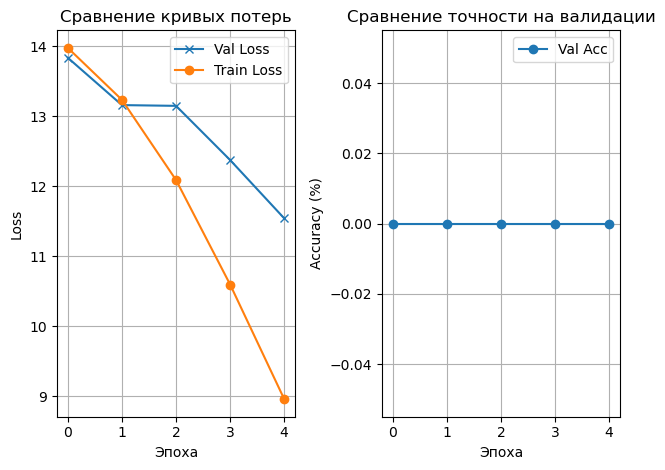

In [25]:
epochs = range(n_epochs)

# Потеря
plt.subplot(1, 2, 1)
plt.plot(epochs, hist['val_loss'], marker='x', label="Val Loss")
plt.plot(epochs, hist['train_loss'], marker='o', label="Train Loss",)
plt.title("Сравнение кривых потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Точность
plt.subplot(1, 2, 2)
plt.plot(range(n_epochs), hist['val_acc'], marker='o', label="Val Acc")
plt.title("Сравнение точности на валидации")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Проверка обученной сети на тестовых данных

In [26]:
# switch the model to inference mode
model_lstm.eval()

# set the empty list of completed texts
completed_texts = []
# set the empty list for predicted parts of texts
output_texts = []


<div class='alert alert-warning'>

Сэмплирование с температурой – костыль, использованный из-за того, что при выборе наиболее подходящего токена через `argmax` он всегда получался одним и  тем же (либо "!", либо "like"). 

</div>

In [27]:

# set the time of the start of execution 
start = datetime.now()

# set the initial counter value (to print only n predictions, but not all)
counter = 0

for i in tqdm(range(len(test_tok_complete))):
    # initialize text for completion
    input_text = test_tok_complete.__getitem__(i)['context']
    # Set the arbitrary non-zero predicted integer (instead of token)
    # to prevent stop while loop before end of completion
    preds_int = 1000
    
    # set count of predicted tokens
    n_tokens = 0

    # Complete the text while model output was not zero 
    # or below 200 words (max length of tweet). 
    while(preds_int != 0 and len(input_text) < 200): 
        
        # get the token predicted by input part of phrase
        # get logits
        x_output = model_lstm(
            # convert text and length to appropriate shape
            input_text.unsqueeze(0), 
            torch.tensor(input_text.shape).view(1)
            )
        # reshape logits array (it needs when test the code, else commented)
        # logits = x_output.flatten(start_dim=1)
        # print(logits)

        # get logit for the last token
        last_token_logits = x_output[:, -1, :] 

        # Because of the model picks the most probable logit and give us the equal result 
        # for each analyzed tweet, we should use the 'temperature sampling' to make the 
        # predictions more diverse. 
        # set the temperature
        temperature = 0.7 
        # calculate the tensor of probabilities of the tokens
        probs = torch.softmax(last_token_logits / temperature, dim=-1)

        # get random token based on `probs`
        preds = torch.multinomial(probs, num_samples=1)[0]

        # get modal value of logits
        preds = torch.multinomial(probs, num_samples=1)[0]
        # print(preds)

        # get value to check stop condition of the 'while' loop
        preds_int = preds.item()

        # add the token to 'input_text', i.e., to phrase to completion
        input_text = torch.cat(
            (input_text, preds.to(input_text.dtype).view(-1)), 
            dim=0
            )
        # print(input_text)
        
        # Create ('if') or update ('else') the predicted part 
        # of the text to ROUGE calculation. 
        if n_tokens == 0:
            output_text = preds
            n_tokens += 1
        else: 
            output_text = torch.cat(
                (output_text, preds.to(output_text.dtype).view(-1)), 
                dim=0
            )

    # decode the completed text
    input_text = tokenizer.decode(input_text, skip_special_tokens=True)
    output_text = tokenizer.decode(output_text, skip_special_tokens=True)
    
    # print completed text
    if counter < 5:
        tqdm.write(f'Входящий текст и дополнение № {counter + 1}')
        tqdm.write(input_text)
        tqdm.write(input_text + output_text)
        counter += 1
        tqdm.write(15 * '-')

    # add the decoded text to another completed texts from the batch
    completed_texts.append(list(filter(None, input_text.split(' '))))
    output_texts.append(list(output_text.split(' ')))


# print the time of execution
finish = datetime.now() - start
mean_time = finish.total_seconds() / len(test_tok_complete)
print(f'Время дополнения одной фразы самописной RNN равно {mean_time:.3f} секунд.')
    

  0%|          | 0/85 [00:00<?, ?it/s]

Входящий текст и дополнение № 1
 im gonna get up late tomorrow and its 132am here i gonna get tipsy by my l do hatedlla by why atuck hold good im dont an see seem fav much im im away want m watching dont film not the sophnt need seem coming punch foo buffalo week watching post hated added appliedia my it im was im i from addedched album w on be be have atched buffalo burned doesnt contacts make stomach hel not punch understood 3 watching from this is for yesched with thisifched doeps goes at dont this sad latekk make without comingnt yesterday middle dbkk without made hold hopegh a talk that im froms added lip holdillian 3 crying nice really if best in please didntched loads10 know do like way all row have lipar made shopping at seekk hope floor im b shopping in though butooumgh late not gets mean 8 so im watching trade at im bypass finish seemia talking really yes makeong in already gets all if talkifers imita go back
 im gonna get up late tomorrow and its 132am here i gonna get tipsy

In [28]:
# the empty list for target phrases
output_targets = []

# fill the 'output_targets'
for _ in range(len(test_tok_complete)):
    # get the tokinized target
    output_target = test_tok_complete.__getitem__(_)['target']
    # decode the target
    output_target = tokenizer.decode(output_target, skip_special_tokens=True)
    # add the target to 'output_targets'
    output_targets.append(list(filter(None, output_target.split(' '))))


In [29]:
# initiate the metric values by zeros
rouge1 = 0.
rouge2 = 0.

# calculate the sum of ROUGE1 and ROUGE2 for the whole data set
for _ in range(len(output_texts)): 
    rouge1 += metric_scorer.score(
        ' '.join(output_texts[_]), 
        ' '.join(output_targets[_]))['rouge1'].fmeasure
    rouge2 += metric_scorer.score(
        ' '.join(output_texts[_]), 
        ' '.join(output_targets[_]))['rouge2'].fmeasure

# calculate the mean ROUGE1 and ROUGE2 and display them
print('Метрики качества самописной сети: ')
print()
print(f'ROUGE1 = {(rouge1 / len(output_texts)):.4f} | ROUGE2 = {(rouge2 / len(output_texts)):.4f}') 

Метрики качества самописной сети: 

ROUGE1 = 0.0118 | ROUGE2 = 0.0000


## DistilGPT2

<div class='alert alert-info'>

Предобученная модель из `Transformers`
В качестве предобученной модели используйте `distilgpt2`. Она хороша тем, что:

- Хорошо работает «из коробки» без дообучения.
- Её просто использовать с `transformers.pipeline`:

`from transformers import pipeline`

`generator = pipeline("text-generation", model="distilgpt2")`

`result = generator("Я собираюсь", max_length=20, do_sample=True, top_k=50)`

`print(result[0]["generated_text"])`

- Она быстрая и не требует большого количества памяти.

</div>

In [30]:
generator = pipeline("text-generation", model="distilgpt2", tokenizer=tokenizer)
logging.set_verbosity_error() 
# set the empty list of completed texts
completed_texts = []
# set the empty list for predicted parts of texts
output_texts = []

# set the time of the start of execution 
start = datetime.now()

# set the initial counter value (to print only n predictions, but not all)
counter = 0

for i in tqdm(range(len(test_tok_complete))):
    # initialize text for completion
    input_tokens = test_tok_complete[i]['context']
    
    # get the length of input tokens sequence
    input_len = len(input_tokens)

    # decode the input text
    input_text = tokenizer.decode(input_tokens, skip_special_tokens=True)

    # set the maximal length of the phrase and number of new tokens
    max_total_limit = 200
    new_tokens_limit = max(1, max_total_limit - input_len)

    # generate the new text
    output_text = generator(
        input_text, 
        max_new_tokens=new_tokens_limit,
        max_length=None, 
        do_sample=True, 
        truncation=True, 
        top_k=50, 
        pad_token_id=tokenizer.eos_token_id
        )
    
    # print completed text
    if counter < 5:
        tqdm.write(f'Входящий текст и сгенерированный текст № {counter + 1}')
        tqdm.write(input_text)
        tqdm.write(output_text[0]['generated_text'])
        counter += 1
        tqdm.write(15 * '-')
        
    # add the decoded text to another completed texts from the batch
    completed_texts.append(output_text[0]['generated_text'].split(' '))
    output_texts.append(
        output_text[0]['generated_text'][len(input_text):].split(' ')
        )
    
# print the time of execution
finish = datetime.now() - start
mean_time = finish.total_seconds() / len(test_tok_complete)
print(f'Время дополнения одной фразы с помощью distilgpt2 равно {mean_time:.3f} секунд.')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

Входящий текст и сгенерированный текст № 1
 im gonna get up late tomorrow and its 132am here i gonna get tipsy by my l
 im gonna get up late tomorrow and its 132am here i gonna get tipsy by my lmao and i am gonna try to save a lil bit of time i am going to get a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna try to save a lil bit of time i'm gonna
---------------
Входящий текст и сгенерированный текст № 2
 never been able to afford to get them out id much rather go through the extraction than con

In [31]:
# initiate the metric values by zeros
rouge1 = 0.
rouge2 = 0.

# calculate the sum of ROUGE1 and ROUGE2 for the whole data set
for _ in range(len(output_texts)): 
    rouge1 += metric_scorer.score(
        ' '.join(output_texts[_]), 
        ' '.join(output_targets[_]))['rouge1'].fmeasure
    rouge2 += metric_scorer.score(
        ' '.join(output_texts[_]), 
        ' '.join(output_targets[_]))['rouge2'].fmeasure

# calculate the mean ROUGE1 and ROUGE2 and display them
print('Метрики качества distilgpt2: ')
print()
print(f'ROUGE1 = {(rouge1 / len(output_texts)):.4f} | ROUGE2 = {(rouge2 / len(output_texts)):.4f}') 

Метрики качества distilgpt2: 

ROUGE1 = 0.0396 | ROUGE2 = 0.0063


# Выводы

<div class='alert alert-info'>

На глаз дополнение, выполненное DistilGPT2, выглядит более адекватным. 

По результатам последнего прогона кода на локальном компьютере: 

- метрики хоть немного, но лучше у DistilGPT2 (ROUGE1 = 0.0396, ROUGE2 = 0.0063) по сравнению с самописной моделью (ROUGE1 = 0.0118, ROUGE2 = 0.0000). 

- скорость работы DistilGPT2 выше в ~2 раза (1.867 и 3.670 с).

**Общий вывод**: использовать следует DistilGPT2. 

</div>